Import Libraries


In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


load the dataset

In [ ]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [194]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [195]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_24432\1251615841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition',data=df,ax=ax[0], palette='Set1')


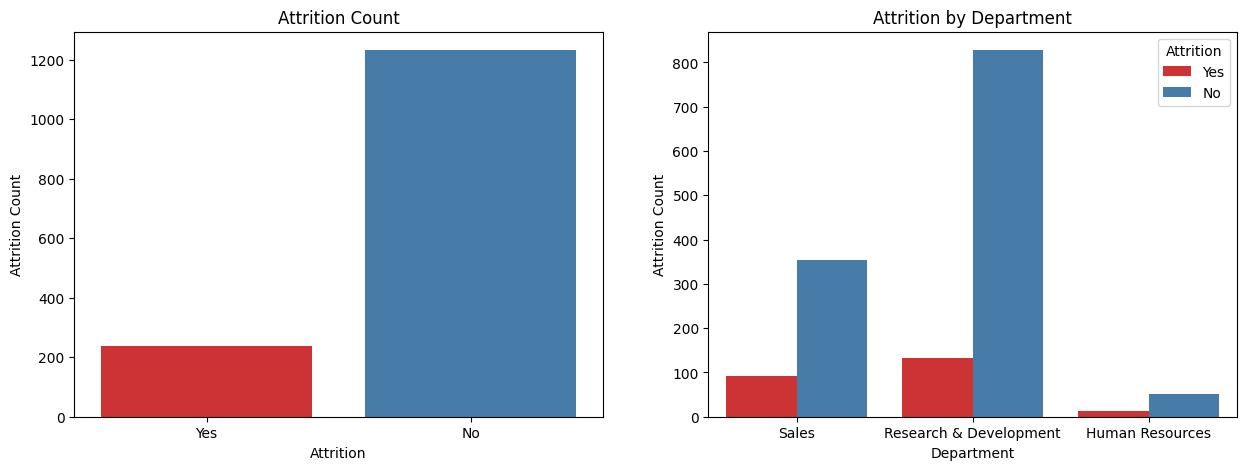

In [196]:
fig,ax=plt.subplots(1,2, figsize=(15,5))
sns.countplot(x='Attrition',data=df,ax=ax[0], palette='Set1')
ax[0].set_title('Attrition Count')
ax[0].set_ylabel('Attrition Count')
sns.countplot(ax=ax[1],data=df,x='Department',hue='Attrition', palette='Set1')
ax[1].set_title('Attrition by Department')
ax[1].set_ylabel('Attrition Count')
plt.show()
fig.savefig('Attrition by Department.png')

Does Numerical factors affect who leaves?

In [197]:
df.select_dtypes(include=['int64']).columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

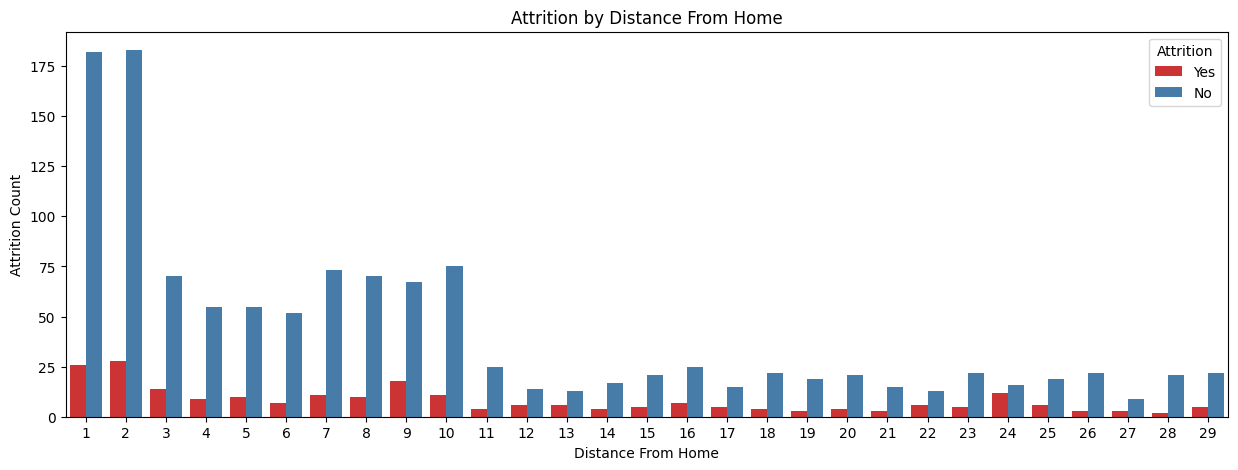

In [198]:
fig,ax=plt.subplots(figsize=(15,5))
sns.countplot(x='DistanceFromHome',data=df,hue='Attrition',palette='Set1')
ax.set_title('Attrition by Distance From Home')
ax.set_ylabel('Attrition Count')
ax.set_xlabel('Distance From Home')
plt.show()
fig.savefig('Attrition by Distance From Home.png')

The majority of employees who live close to the workplace (1–2 units of distance) show lower attrition rates compared to those living farther away. This indicates that commute length is a significant factor influencing retention. To reduce attrition, HR could consider policies such as remote work options, relocation assistance, or transport benefits for employees with longer commutes

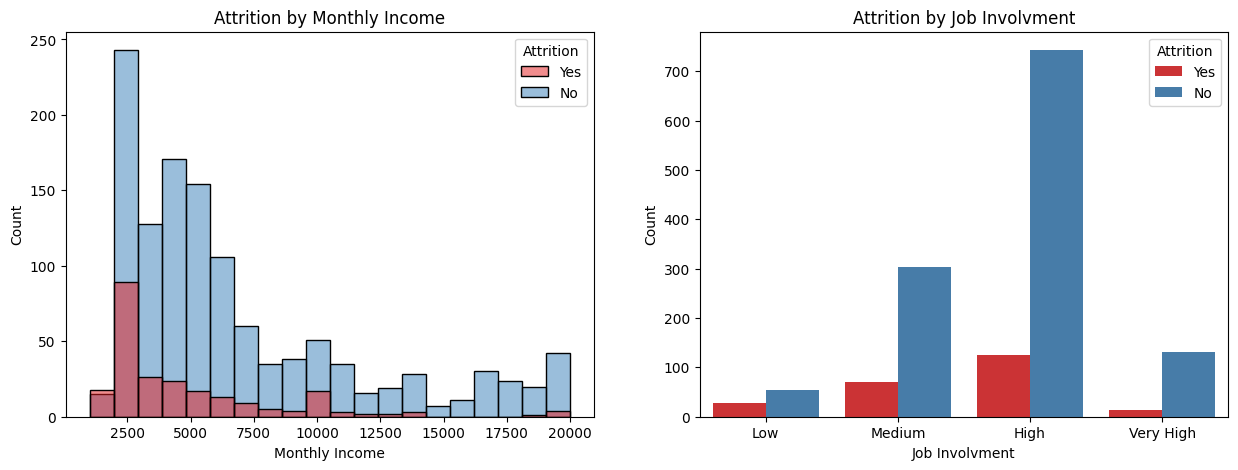

In [199]:
## monthly income and attrition
fig,ax=plt.subplots(1,2, figsize=(15,5))
sns.histplot(data=df,x='MonthlyIncome',hue='Attrition',palette='Set1',ax=ax[0])
ax[0].set_title('Attrition by Monthly Income')
ax[0].set_xlabel('Monthly Income')
ax[0].set_ylabel('Count')

## job Involvment and attrition
sns.countplot(x='JobInvolvement',data=df,hue='Attrition',ax=ax[1],palette='Set1')
ax[1].set_title('Attrition by Job Involvment')
ax[1].set_xlabel('Job Involvment')
ax[1].set_ylabel('Count') 
ax[1].set_xticks([0, 1, 2, 3])
ax[1].set_xticklabels(['Low', 'Medium', 'High', 'Very High'])  

plt.show()
fig.savefig('Attrition by Monthly Income and Job Involvment.png')

Attrition is strongly influenced by both financial and engagement factors. Employees with lower incomes and lower job involvement are more likely to leave, highlighting the importance of addressing both compensation and workplace engagement. A dual strategy is improving pay structures and fostering stronger employee involvement which can significantly reduce turnover

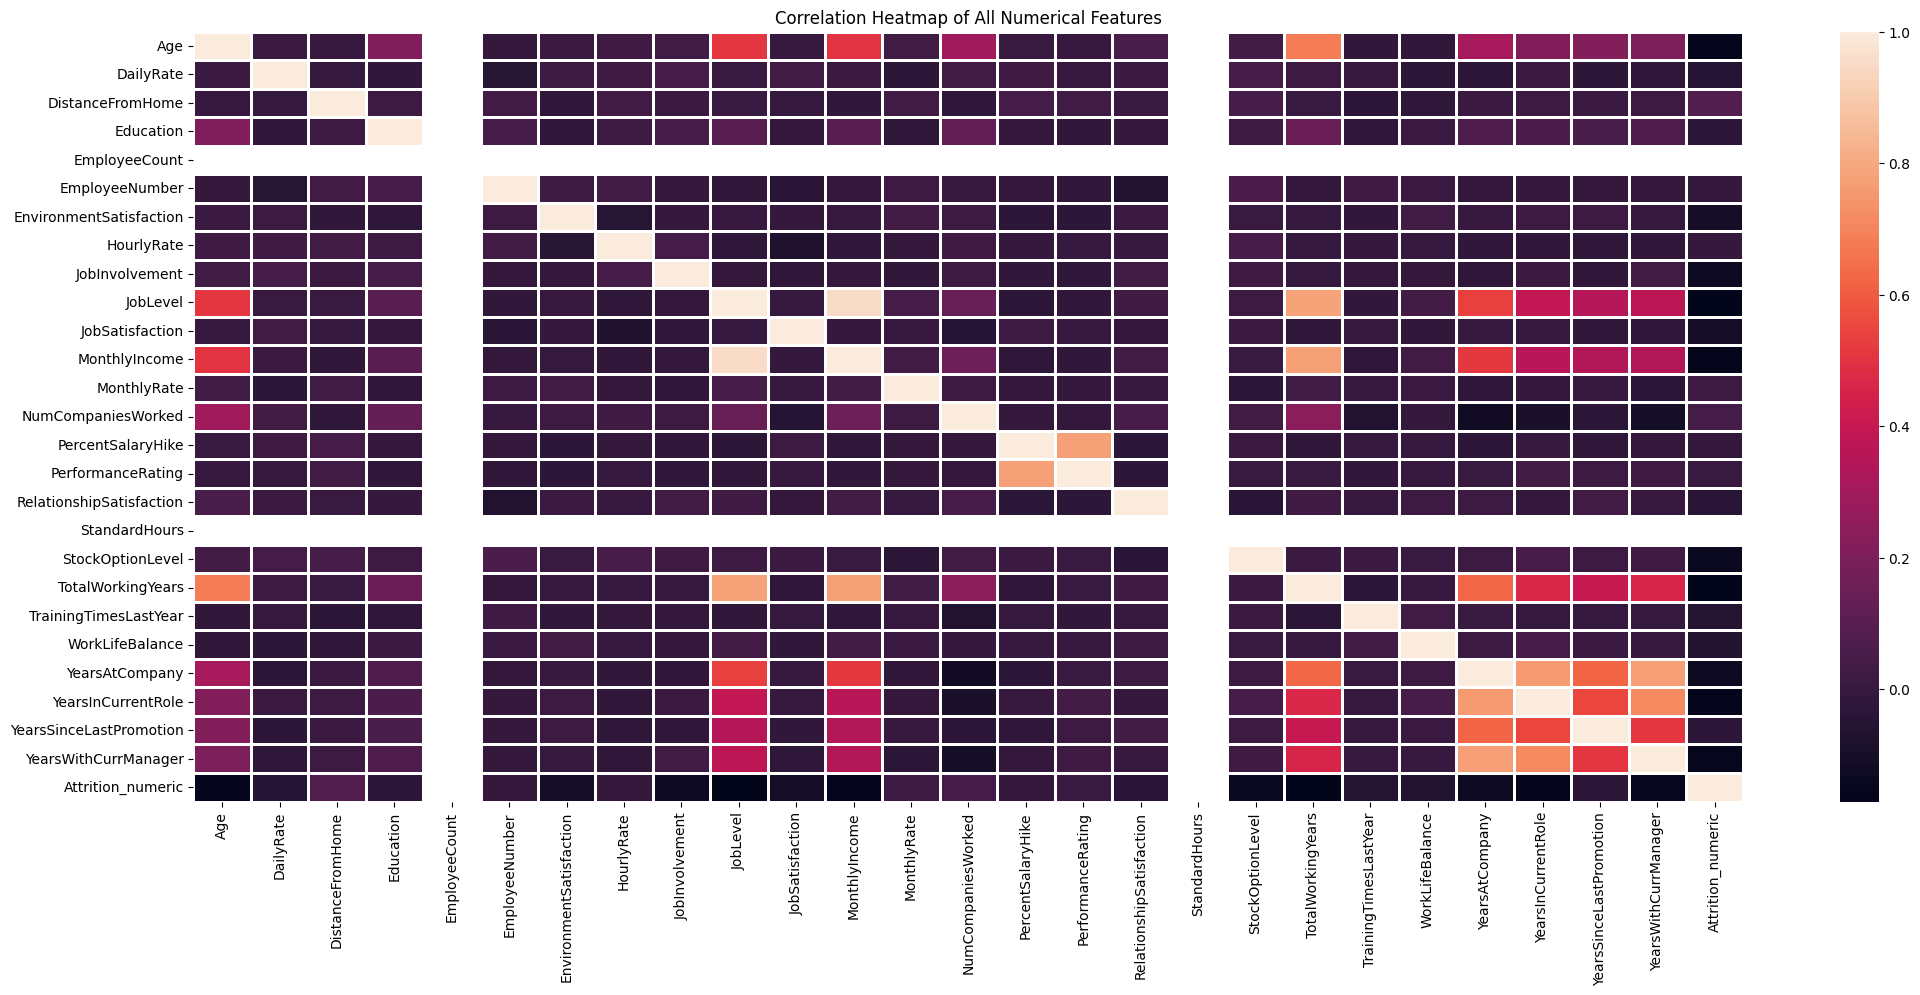

Attrition_numeric          1.000000
DistanceFromHome           0.077924
NumCompaniesWorked         0.043494
MonthlyRate                0.015170
PerformanceRating          0.002889
HourlyRate                -0.006846
EmployeeNumber            -0.010577
PercentSalaryHike         -0.013478
Education                 -0.031373
YearsSinceLastPromotion   -0.033019
Name: Attrition_numeric, dtype: float64
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_numeric, dtype: float64


In [200]:
## heat map of correlation
## convert atrrition to number
df['Attrition_numeric'] = df['Attrition'].map(
    {'Yes': 1,
      'No': 0
    })
df['Attrition_numeric'].value_counts()
df_numeric=df.select_dtypes(include=[int,float])
df_numeric.head()

corr_matrix=df_numeric.corr()
corr_matrix
fig,ax=plt.subplots(figsize=(25,10))
sns.heatmap(corr_matrix,annot=False, linewidths=1)
plt.title('Correlation Heatmap of All Numerical Features')
plt.show()
print(corr_matrix['Attrition_numeric'].sort_values(ascending=False).head(10))
print(corr_matrix['Attrition_numeric'].sort_values().head(10))
fig.savefig('Correlation Heatmap of All Numerical Features.png')

Core Factors Resulting to Attrition 
1. DistanceFromHome           0.077924 (Employees living farther away are slightly more likely to leave due to commute stress.)
2. NumCompaniesWorked         0.043494 (Employees with more prior employers tend to leave more, suggesting job-hopping behavior.)
3. MonthlyRate                0.015170 (Very weak link, but irregular pay structures may contribute marginally.)
4. PerformanceRating          0.002889 (Almost no effect, showing performance scores don’t strongly predict attrition.)
5. HourlyRate                -0.006846 (Slight negative correlation, essentially negligible.)
##### These factors have weak correlations, meaning they don’t strongly drive attrition on their own. However, commute distance and career history (job-hopping) are modest contributors.

Core Factors resulting to no Attrition
1. TotalWorkingYears      -0.171063 (Experienced employees are more loyal and less likely to leave.)
2. JobLevel               -0.169105 (Senior employees show stronger retention, likely due to stability and benefits.)
3. YearsInCurrentRole     -0.160545 (Longer role tenure reduces attrition, suggesting role familiarity builds commitment.)
4. MonthlyIncome          -0.159840 (Higher income strongly supports retention.)
5. Age                    -0.159205 (Older employees are less likely to leave, while younger employees show higher attrition.)
##### These factors have stronger correlations compared to attrition drivers. They highlight that tenure, seniority, compensation, and age are the most important anchors for retention.

### Attrition is weakly linked to external stressors like commute distance and prior job changes, while retention is strongly tied to tenure, compensation, and career maturity. This means HR should prioritize strategies that support younger, lower-level employees with clear career paths, competitive pay, and engagement initiatives, while also addressing commute challenges for those living farther away.